# 🦁 MUFASAR — ADTC Profiler Multi-Model Benchmark
**Africa Deep Tech Challenge 2026 · CPU-only**

This notebook uses the **official `adtc-profiler` measurement modules directly**:

- `adtc_profiler.throughput` → native `llama-bench` generation speed and first-token latency
- `adtc_profiler.memory` → peak and steady-state process-tree RSS
- `adtc_profiler.thermal` → CPU utilisation, temperature, and throttling
- `adtc_profiler.accuracy` → `lm-eval` ARC-Easy accuracy on each quantized GGUF

There are **no hand-written benchmark questions, no chat prompts, and no submission metadata**. Each model is downloaded, profiled sequentially with the same ADTC workload, written to its own JSON report, then removed to reclaim disk space.

### Model set

| Model | Size tier | Profiler runtime |
|---|---:|---|
| **Qwen3.5-4B Q4_K_M** | **4B** | upstream `llama-bench` + standard profiler accuracy adapter |
| **Qwen3.5-2B Q4_K_M** | **2B** | upstream profiler path |
| **Phi-4 Mini Reasoning** | **3.8B** | smallest Phi-4-family model; upstream profiler path |
| Gemma-3-4B-IT | 4B | upstream profiler path |
| **Gemma-3-1B-IT** | **1B** | upstream profiler path |
| **Gemma-4-E2B-IT Q4_K_M** | **effective 2B** | current upstream `llama-bench` + guarded current Python accuracy adapter |
| **Gemma-4-E4B-IT Q4_K_M** | **effective 4B** | current upstream `llama-bench` + guarded current Python accuracy adapter |
| **LiquidAI LFM2.5-2.6B** | **2.6B** | current upstream `llama-bench` + guarded current Python accuracy adapter |
| **LiquidAI LFM2.5-1.2B-Thinking** | **1.2B** | current upstream `llama-bench` + guarded current Python accuracy adapter |

> Gemma 4 does not have a 1B tier. Google's compact Gemma 4 tiers are **E2B** and **E4B**, so E2B is used as the closest small Gemma 4 model.

> All models receive the same official ADTC throughput/latency/memory/thermal workload and the same ARC-Easy accuracy limit.

> LiquidAI LFM2.5 and Gemma 4 use current upstream `llama.cpp`. For accuracy, the notebook first probes the installed `llama-cpp-python`; if it is too old for either architecture, it builds one isolated current upstream binding and retries without affecting the standard models.

> Enable **Internet** in Kaggle before running.


In [1]:
# 1. Install the official profiler and its accuracy stack.
import subprocess
import sys

packages = [
    "adtc-profiler[accuracy] @ git+https://github.com/Africa-Deep-Tech-Foundation/adtc-profiler.git",
    "llama-cpp-python>=0.3.34,<0.4",
    "huggingface_hub>=0.30,<2",
    "psutil>=5.9",
    "tabulate>=0.9",
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--prefer-binary",
] + packages)

print("✅ Official ADTC profiler and accuracy dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.3 MB/s eta 0:00:00
✅ Official ADTC profiler and accuracy dependencies installed


In [2]:
# 2. Imports and profiler configuration.
import contextlib
import gc
import importlib.metadata
import json
import os
import re
import shutil
import subprocess
import sys
import time
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psutil
from huggingface_hub import HfApi, hf_hub_download
from tabulate import tabulate

from adtc_profiler import accuracy as adtc_accuracy
from adtc_profiler import environment as adtc_environment
from adtc_profiler import memory as adtc_memory
from adtc_profiler import thermal as adtc_thermal
from adtc_profiler import throughput as adtc_throughput

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "mufasar_models"
RUNTIME_DIR = WORK_DIR / "mufasar_runtimes"
ARTIFACT_DIR = WORK_DIR / "mufasar_profiler_artifacts"
REPORT_DIR = ARTIFACT_DIR / "model_reports"

# Gemma 4 and LiquidAI LFM2.5 are recent llama.cpp architectures. The isolated
# current-upstream Python binding is built only if the installed llama-cpp-python
# cannot load one of these GGUFs during the profiler accuracy stage.
CURRENT_PY_SOURCE = RUNTIME_DIR / "llama-cpp-python-current"
CURRENT_PY_SITE = RUNTIME_DIR / "current_python_site"
CURRENT_PY_MARKER = CURRENT_PY_SITE / ".current_backend_ready"

for directory in (MODEL_DIR, RUNTIME_DIR, ARTIFACT_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_THREADS = max(1, min(8, os.cpu_count() or 4))
SEED = 42

# Identical native profiler workload for every registered model.
PROFILER_PROMPT_TOKENS = 128
PROFILER_GENERATED_TOKENS = 32

# Official lm-eval task used by adtc-profiler. Increase to 50 for the repository
# default when runtime permits; every model receives the same limit.
ACCURACY_TASK = "arc_easy"
ACCURACY_LIMIT = 10
ACCURACY_TIMEOUT_SECONDS = 15 * 60

DELETE_MODEL_AFTER_PROFILE = True
BUILD_JOBS = max(1, min(4, N_THREADS))

os.environ.update({
    "OMP_NUM_THREADS": str(N_THREADS),
    "OPENBLAS_NUM_THREADS": str(N_THREADS),
    "MKL_NUM_THREADS": str(N_THREADS),
    "NUMEXPR_NUM_THREADS": str(N_THREADS),
    "TOKENIZERS_PARALLELISM": "false",
    "HF_HUB_DOWNLOAD_TIMEOUT": "300",
    "HF_HUB_ETAG_TIMEOUT": "90",
})

print(f"CPU threads: {N_THREADS}")
print(f"Profiler tokens: pp={PROFILER_PROMPT_TOKENS}, tg={PROFILER_GENERATED_TOKENS}")
print(f"Accuracy: {ACCURACY_TASK}, limit={ACCURACY_LIMIT}")


CPU threads: 4
Profiler tokens: pp=128, tg=32
Accuracy: arc_easy, limit=10


In [3]:
# 3. Model and runtime registries. No benchmark prompts are defined anywhere in this notebook.
MODELS = {
    "Qwen3.5-4B-Q4_K_M": {
        "repo_candidates": [
            {"repo": "unsloth/Qwen3.5-4B-GGUF", "filename": "Qwen3.5-4B-Q4_K_M.gguf"},
            {"repo": "unsloth/Qwen3.5-4B-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "standard",
        "quantization": "Q4_K_M",
        "color": "#E87D2E",
    },
    "Qwen3.5-2B-Q4_K_M": {
        "repo_candidates": [
            {"repo": "unsloth/Qwen3.5-2B-GGUF", "filename": "Qwen3.5-2B-Q4_K_M.gguf"},
            {"repo": "unsloth/Qwen3.5-2B-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "standard",
        "quantization": "Q4_K_M",
        "color": "#F4B400",
    },
    "Phi-4-Mini-Reasoning": {
        "repo_candidates": [
            {"repo": "Mungert/Phi-4-mini-reasoning-GGUF", "filename": "Phi-4-mini-reasoning-q4_k_m.gguf"},
            {"repo": "Mungert/Phi-4-mini-reasoning-GGUF", "pattern": "*q4_k_m.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "standard",
        "quantization": "Q4_K_M",
        "color": "#0078D4",
    },
    "Gemma-3-4B-IT": {
        "repo_candidates": [
            {"repo": "lmstudio-community/gemma-3-4b-it-GGUF", "filename": "gemma-3-4b-it-Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "standard",
        "quantization": "Q4_K_M",
        "color": "#34A853",
    },
    "Gemma-3-1B-IT-Q4_K_M": {
        "repo_candidates": [
            {"repo": "lmstudio-community/gemma-3-1b-it-GGUF", "filename": "gemma-3-1b-it-Q4_K_M.gguf"},
            {"repo": "lmstudio-community/gemma-3-1b-it-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "standard",
        "quantization": "Q4_K_M",
        "color": "#00A6A6",
    },
    "Gemma-4-E2B-IT-Q4_K_M": {
        "repo_candidates": [
            {"repo": "bartowski/google_gemma-4-E2B-it-GGUF", "filename": "google_gemma-4-E2B-it-Q4_K_M.gguf"},
            {"repo": "bartowski/google_gemma-4-E2B-it-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "current_python",
        "quantization": "Q4_K_M",
        "color": "#7E57C2",
    },
    "Gemma-4-E4B-IT-Q4_K_M": {
        "repo_candidates": [
            {"repo": "bartowski/google_gemma-4-E4B-it-GGUF", "filename": "gemma-4-E4B-it-Q4_K_M.gguf"},
            {"repo": "llmware/gemma-4-4b-it-gguf", "filename": "gemma-4-E4B-it-Q4_K_M.gguf"},
            {"repo": "bartowski/google_gemma-4-E4B-it-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "current_python",
        "quantization": "Q4_K_M",
        "color": "#5E35B1",
    },
    "LFM2.5-2.6B-Q4_K_M": {
        "repo_candidates": [
            {"repo": "LiquidAI/LFM2.5-2.6B-GGUF", "filename": "LFM2.5-2.6B-Q4_K_M.gguf"},
            {"repo": "LiquidAI/LFM2.5-2.6B-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "current_python",
        "quantization": "Q4_K_M",
        "color": "#FF6F61",
    },
    "LFM2.5-1.2B-Thinking-Q4_K_M": {
        "repo_candidates": [
            {"repo": "LiquidAI/LFM2.5-1.2B-Thinking-GGUF", "filename": "LFM2.5-1.2B-Thinking-Q4_K_M.gguf"},
            {"repo": "LiquidAI/LFM2.5-1.2B-Thinking-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "runtime": "upstream",
        "accuracy_backend": "current_python",
        "quantization": "Q4_K_M",
        "color": "#C2185B",
    },
}

# Keep runtime definitions beside MODELS so edits cannot silently remove them.
RUNTIMES = {
    "upstream": {
        "repo": "https://github.com/ggml-org/llama.cpp.git",
        "branch": None,
    },
}

# Fail immediately during configuration if a future edit drops/misspells a runtime.
required_runtimes = {cfg["runtime"] for cfg in MODELS.values()}
missing_runtimes = required_runtimes.difference(RUNTIMES)
if missing_runtimes:
    raise RuntimeError(f"MODELS references undefined runtimes: {sorted(missing_runtimes)}")

SUPPORTED_ACCURACY_BACKENDS = {"standard", "current_python"}
for model_name, cfg in MODELS.items():
    if not cfg.get("repo_candidates"):
        raise RuntimeError(f"{model_name} has no download candidates")
    if cfg.get("accuracy_backend") not in SUPPORTED_ACCURACY_BACKENDS:
        raise RuntimeError(
            f"{model_name} has unsupported accuracy backend: {cfg.get('accuracy_backend')}"
        )

print(f"✅ Registered {len(MODELS)} models and {len(RUNTIMES)} runtimes")


✅ Registered 9 models and 1 runtimes


In [4]:
# 4. Download and runtime helpers.
import fnmatch

HF_API = HfApi()


def run_checked(command, *, cwd=None, timeout=None, log_path=None, env=None):
    command = [str(item) for item in command]
    print("$", " ".join(command), flush=True)
    completed = subprocess.run(
        command,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
        check=False,
        env=env,
    )
    output = completed.stdout or ""
    if log_path is not None:
        Path(log_path).write_text(output, encoding="utf-8")
    if completed.returncode != 0:
        tail = "\n".join(output.splitlines()[-100:])
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}: "
            f"{' '.join(command)}\n{tail}"
        )
    return output


def release_memory():
    gc.collect()
    try:
        import ctypes
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass


def resolve_candidate(candidate):
    repo = candidate["repo"]
    filename = candidate.get("filename")
    if filename:
        return repo, filename

    pattern = candidate.get("pattern")
    if not pattern:
        raise ValueError(f"Candidate has neither filename nor pattern: {candidate}")

    files = HF_API.list_repo_files(repo_id=repo)
    matches = [
        name for name in files
        if Path(name).name.lower().endswith(".gguf")
        and fnmatch.fnmatch(Path(name).name.lower(), pattern.lower())
    ]
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern!r} in {repo}")
    matches.sort(key=lambda name: ("/" in name, len(name), name.lower()))
    return repo, matches[0]


def download_model(model_name, config):
    errors = []
    model_dir = MODEL_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    for candidate in config["repo_candidates"]:
        try:
            repo, filename = resolve_candidate(candidate)
            print(f"Downloading {model_name}: {repo}/{filename}")
            downloaded = Path(hf_hub_download(
                repo_id=repo,
                filename=filename,
                local_dir=str(model_dir),
            ))
            if not downloaded.exists() or downloaded.stat().st_size < 100_000_000:
                raise OSError(f"Downloaded file is missing or implausibly small: {downloaded}")
            return downloaded, repo, filename
        except Exception as exc:
            errors.append(f"{candidate}: {type(exc).__name__}: {exc}")

    raise RuntimeError(
        f"Every download candidate failed for {model_name}:\n" + "\n".join(errors)
    )


def locate_binary(root, name):
    preferred = [
        root / "build" / "bin" / name,
        root / "build" / name,
        root / name,
    ]
    for path in preferred:
        if path.exists() and os.access(path, os.X_OK):
            return path
    for path in root.rglob(name):
        if path.is_file() and os.access(path, os.X_OK):
            return path
    return None


def ensure_llama_bench(runtime_name):
    config = RUNTIMES[runtime_name]
    source_dir = RUNTIME_DIR / f"{runtime_name}-llama.cpp"
    build_dir = source_dir / "build"

    existing = locate_binary(source_dir, "llama-bench") if source_dir.exists() else None
    if existing is not None:
        return existing

    if source_dir.exists():
        shutil.rmtree(source_dir)

    clone_command = ["git", "clone", "--depth", "1"]
    if config.get("branch"):
        clone_command += ["--branch", config["branch"]]
    clone_command += [config["repo"], source_dir]

    run_checked(
        clone_command,
        timeout=600,
        log_path=ARTIFACT_DIR / f"{runtime_name}_clone.log",
    )

    configure_command = [
        "cmake",
        "-S", source_dir,
        "-B", build_dir,
        "-DGGML_CUDA=OFF",
        "-DGGML_NATIVE=ON",
        "-DGGML_CCACHE=OFF",
        "-DLLAMA_CURL=OFF",
        "-DLLAMA_BUILD_TESTS=OFF",
        "-DLLAMA_BUILD_SERVER=OFF",
        "-DLLAMA_BUILD_EXAMPLES=ON",
        "-DCMAKE_BUILD_TYPE=Release",
    ]
    run_checked(
        configure_command,
        timeout=420,
        log_path=ARTIFACT_DIR / f"{runtime_name}_configure.log",
    )
    run_checked(
        [
            "cmake", "--build", build_dir,
            "--config", "Release",
            "-j", str(BUILD_JOBS),
            "--target", "llama-bench",
        ],
        timeout=1800,
        log_path=ARTIFACT_DIR / f"{runtime_name}_build.log",
    )

    binary = locate_binary(source_dir, "llama-bench")
    if binary is None:
        raise FileNotFoundError(
            f"{runtime_name} runtime build did not produce llama-bench"
        )
    return binary


@contextlib.contextmanager
def profiler_runtime(binary):
    # Make the selected fork's llama-bench visible to adtc_profiler.
    alias_dir = binary.parent
    old_path = os.environ.get("PATH", "")
    os.environ["PATH"] = f"{alias_dir}:{old_path}"
    try:
        yield
    finally:
        os.environ["PATH"] = old_path


@contextlib.contextmanager
def configured_profiler_tokens():
    # Keep the official throughput.measure projection, with one shared workload.
    original = adtc_throughput.run_llama_bench

    def configured(model_path, n_prompt=512, n_gen=128, n_threads=None, seed=42):
        return original(
            model_path,
            n_prompt=PROFILER_PROMPT_TOKENS,
            n_gen=PROFILER_GENERATED_TOKENS,
            n_threads=N_THREADS,
            seed=seed,
        )

    adtc_throughput.run_llama_bench = configured
    try:
        yield
    finally:
        adtc_throughput.run_llama_bench = original


print("✅ Runtime helpers ready")


✅ Runtime helpers ready


In [5]:
# 5. Official profiler accuracy runner with a guarded current-upstream loader for recent architectures.
def _prepend_pythonpath(environment, directory):
    current = environment.get("PYTHONPATH", "")
    environment["PYTHONPATH"] = (
        f"{directory}{os.pathsep}{current}" if current else str(directory)
    )
    return environment


def _probe_llama_cpp_model(model_path, custom_site=None, timeout=600, label="backend"):
    """Return (ok, log_text) after proving that a Python binding can load the GGUF."""
    environment = os.environ.copy()
    environment.update({
        "OMP_NUM_THREADS": "1",
        "OPENBLAS_NUM_THREADS": "1",
        "MKL_NUM_THREADS": "1",
        "PYTHONUNBUFFERED": "1",
    })
    if custom_site is not None:
        _prepend_pythonpath(environment, custom_site)
        environment["PYTHONNOUSERSITE"] = "1"

    verify_script = f"""
import gc
import llama_cpp
from llama_cpp import Llama
llm = Llama(
    model_path={str(model_path)!r},
    n_ctx=128,
    n_batch=32,
    n_threads=1,
    n_threads_batch=1,
    n_gpu_layers=0,
    use_mmap=True,
    use_mlock=False,
    verbose=False,
)
print("loaded", getattr(llama_cpp, "__version__", "source-build"))
del llm
gc.collect()
"""
    try:
        completed = subprocess.run(
            [sys.executable, "-c", verify_script],
            env=environment,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            timeout=timeout,
            check=False,
        )
        text = completed.stdout or ""
        return completed.returncode == 0, text
    except subprocess.TimeoutExpired as exc:
        output = exc.stdout or ""
        if isinstance(output, bytes):
            output = output.decode("utf-8", "replace")
        return False, f"{label} probe timed out after {timeout}s\n{output}"
    except Exception as exc:
        return False, f"{label} probe failed: {type(exc).__name__}: {exc}"


def ensure_current_python_backend(model_path, model_name):
    """Use installed llama-cpp-python when possible, else one isolated current build."""
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_name)
    ok, probe_log = _probe_llama_cpp_model(
        model_path, custom_site=None, label=f"{model_name} standard"
    )
    (ARTIFACT_DIR / f"{safe_name}_standard_binding_probe.log").write_text(
        probe_log, encoding="utf-8"
    )
    if ok:
        print(f"→ installed llama-cpp-python already supports {model_name}")
        return None

    if CURRENT_PY_MARKER.exists():
        ok, probe_log = _probe_llama_cpp_model(
            model_path, CURRENT_PY_SITE, label=f"{model_name} isolated"
        )
        (ARTIFACT_DIR / f"{safe_name}_isolated_binding_probe.log").write_text(
            probe_log, encoding="utf-8"
        )
        if ok:
            return CURRENT_PY_SITE
        # Do not trust an old cached build if it cannot load this newer architecture.
        CURRENT_PY_MARKER.unlink(missing_ok=True)

    print(f"→ installed binding cannot load {model_name}; building isolated current llama-cpp-python")
    shutil.rmtree(CURRENT_PY_SOURCE, ignore_errors=True)
    shutil.rmtree(CURRENT_PY_SITE, ignore_errors=True)
    CURRENT_PY_SITE.mkdir(parents=True, exist_ok=True)

    run_checked(
        [
            "git", "clone", "--depth", "1", "--recurse-submodules",
            "https://github.com/abetlen/llama-cpp-python.git",
            CURRENT_PY_SOURCE,
        ],
        timeout=900,
        log_path=ARTIFACT_DIR / "current_python_clone.log",
    )

    build_environment = os.environ.copy()
    build_environment.update({
        "CMAKE_ARGS": (
            "-DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF "
            "-DLLAVA_BUILD=OFF -DLLAMA_CURL=OFF"
        ),
        "CMAKE_BUILD_PARALLEL_LEVEL": str(BUILD_JOBS),
        "FORCE_CMAKE": "1",
    })
    run_checked(
        [
            sys.executable, "-m", "pip", "install", "--no-deps",
            "--no-cache-dir", "--force-reinstall", "--target",
            CURRENT_PY_SITE, CURRENT_PY_SOURCE,
        ],
        timeout=3600,
        env=build_environment,
        log_path=ARTIFACT_DIR / "current_python_build.log",
    )

    ok, probe_log = _probe_llama_cpp_model(
        model_path, CURRENT_PY_SITE, label=f"{model_name} isolated"
    )
    (ARTIFACT_DIR / f"{safe_name}_current_python_verify.log").write_text(
        probe_log, encoding="utf-8"
    )
    if not ok:
        raise RuntimeError(
            f"isolated current llama-cpp-python built but still could not load {model_name}"
        )

    CURRENT_PY_MARKER.write_text(
        "Current upstream Python backend ready\nsource=llama-cpp-python main\n",
        encoding="utf-8",
    )
    return CURRENT_PY_SITE


def run_accuracy_isolated(model_path, model_name, accuracy_backend="standard"):
    """Run the profiler's unmodified ARC-Easy calculation in a clean process."""
    result_path = ARTIFACT_DIR / f"{model_name}_accuracy_result.json"
    if result_path.exists():
        result_path.unlink()

    environment = os.environ.copy()
    environment.update({
        "OMP_NUM_THREADS": str(N_THREADS),
        "OPENBLAS_NUM_THREADS": str(N_THREADS),
        "MKL_NUM_THREADS": str(N_THREADS),
        "PYTHONUNBUFFERED": "1",
    })

    if accuracy_backend == "current_python":
        try:
            custom_site = ensure_current_python_backend(model_path, model_name)
            if custom_site is not None:
                _prepend_pythonpath(environment, custom_site)
                environment["PYTHONNOUSERSITE"] = "1"
        except Exception as exc:
            return {
                "status": "failed",
                "error": (
                    "Current llama-cpp-python compatibility setup failed: "
                    f"{type(exc).__name__}: {exc}"
                ),
            }
    elif accuracy_backend != "standard":
        return {"status": "failed", "error": f"Unknown accuracy backend: {accuracy_backend}"}

    # The official profiler code remains the scorer. PYTHONPATH only swaps the
    # llama_cpp shared library underneath it when a newer loader is required.
    script = f"""
import json
from pathlib import Path
from adtc_profiler import accuracy
output_path = Path({str(result_path)!r})
try:
    result = accuracy.run_benchmark(
        Path({str(model_path)!r}),
        task={ACCURACY_TASK!r},
        limit={int(ACCURACY_LIMIT)},
        seed={int(SEED)},
    )
    payload = {{"status": "ok", "result": result}}
except Exception as exc:
    payload = {{
        "status": "failed",
        "error_type": type(exc).__name__,
        "error": repr(exc),
    }}
output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
"""

    log_path = ARTIFACT_DIR / f"{model_name}_accuracy.log"
    try:
        completed = subprocess.run(
            [sys.executable, "-c", script],
            env=environment,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            timeout=ACCURACY_TIMEOUT_SECONDS,
            check=False,
        )
        log_path.write_text(completed.stdout or "", encoding="utf-8")
    except subprocess.TimeoutExpired as exc:
        timeout_output = exc.stdout or ""
        if isinstance(timeout_output, bytes):
            timeout_output = timeout_output.decode("utf-8", "replace")
        log_path.write_text(timeout_output, encoding="utf-8")
        return {
            "status": "timeout",
            "error": f"Official accuracy exceeded {ACCURACY_TIMEOUT_SECONDS}s",
        }

    if not result_path.exists():
        return {
            "status": "failed",
            "error": (
                f"Accuracy process exited {completed.returncode} without a result file. "
                f"See {log_path.name}"
            ),
        }

    payload = json.loads(result_path.read_text(encoding="utf-8"))
    if completed.returncode != 0 and payload.get("status") == "ok":
        payload["status"] = "failed"
        payload["error"] = f"Accuracy process exited {completed.returncode}"
    return payload


def score_components(throughput_block, memory_block, accuracy_payload, thermal_block):
    accuracy_result = accuracy_payload.get("result") or {}
    accuracy_score = float(accuracy_result.get("score") or 0.0) * 100.0

    tps = float(throughput_block.get("tokens_per_second_generation") or 0.0)
    performance_score = min(tps / 15.0, 1.0) * 100.0

    peak_rss_mb = float(memory_block.get("peak_rss_mb") or 0.0)
    ram_limit_mb = 7.0 * 1024.0
    efficiency_score = max(0.0, (ram_limit_mb - peak_rss_mb) / ram_limit_mb) * 100.0

    peak_temp = thermal_block.get("core_temp_c_peak")
    throttled = bool(thermal_block.get("throttled"))
    thermal_penalty = 10.0 if throttled or (
        isinstance(peak_temp, (int, float)) and peak_temp > 85.0
    ) else 0.0

    total = (
        0.50 * accuracy_score
        + 0.30 * performance_score
        + 0.20 * efficiency_score
        - thermal_penalty
    )
    return {
        "accuracy_component_100": round(accuracy_score, 4),
        "performance_component_100": round(performance_score, 4),
        "efficiency_component_100": round(efficiency_score, 4),
        "thermal_penalty": round(thermal_penalty, 4),
        "estimated_total_100": round(total, 4),
        "estimated_total_0_to_1": round(total / 100.0, 6),
    }


print("✅ Official accuracy + guarded current-upstream backend helpers ready")


✅ Official accuracy + guarded current-upstream backend helpers ready


In [6]:
# 6. Profile every model. Failures are contained and written to the report.
ALL_REPORTS = []
ERROR_ROWS = []

environment_snapshot = adtc_environment.capture("participant_laptop")

for index, (model_name, config) in enumerate(MODELS.items(), start=1):
    print("\n" + "=" * 90)
    print(f"[{index}/{len(MODELS)}] {model_name}")
    print("=" * 90)

    model_path = None
    report = {
        "model": model_name,
        "quantization": config["quantization"],
        "runtime": config["runtime"],
        "accuracy_backend": config.get("accuracy_backend", "standard"),
        "environment": environment_snapshot,
        "status": "started",
    }

    started = time.time()
    try:
        model_path, repo, filename = download_model(model_name, config)
        report.update({
            "repo": repo,
            "filename": filename,
            "model_size_gb": round(model_path.stat().st_size / 1e9, 4),
        })

        bench_binary = ensure_llama_bench(config["runtime"])
        report["llama_bench_binary"] = str(bench_binary)

        with profiler_runtime(bench_binary), configured_profiler_tokens():
            with (
                adtc_memory.sample_during() as memory_sampler,
                adtc_thermal.sample_thermal() as thermal_sampler,
            ):
                print("→ official profiler throughput / latency / memory / thermal")
                throughput_block = adtc_throughput.measure(model_path, seed=SEED)
            memory_block = memory_sampler.report()
            thermal_block = thermal_sampler.report()

        report["throughput"] = throughput_block
        report["memory"] = memory_block
        report["cpu_thermal"] = thermal_block
        report["performance_status"] = "ok"

        print("→ official profiler ARC-Easy accuracy")
        accuracy_payload = run_accuracy_isolated(
            model_path,
            model_name,
            config.get("accuracy_backend", "standard"),
        )
        report["accuracy_status"] = accuracy_payload.get("status", "failed")
        report["accuracy"] = (
            [accuracy_payload["result"]]
            if accuracy_payload.get("status") == "ok" and accuracy_payload.get("result")
            else []
        )
        if accuracy_payload.get("status") != "ok":
            report["accuracy_error"] = accuracy_payload.get(
                "error", "unknown accuracy error"
            )

        report["score"] = score_components(
            throughput_block,
            memory_block,
            accuracy_payload,
            thermal_block,
        )
        report["status"] = (
            "ok"
            if report["accuracy_status"] == "ok"
            else "performance_ok_accuracy_unavailable"
        )

    except Exception as exc:
        report["status"] = "failed"
        report["error_type"] = type(exc).__name__
        report["error"] = repr(exc)
        report["traceback_tail"] = traceback.format_exc().splitlines()[-30:]
        ERROR_ROWS.append({
            "model": model_name,
            "stage": report.get("performance_status", "setup_or_performance"),
            "error": repr(exc),
        })
        print(f"❌ {model_name}: {exc}")

    finally:
        report["elapsed_s"] = round(time.time() - started, 2)
        report_path = REPORT_DIR / f"{index:02d}_{model_name}.json"
        report_path.write_text(
            json.dumps(report, indent=2, ensure_ascii=False) + "\n",
            encoding="utf-8",
        )
        ALL_REPORTS.append(report)

        if DELETE_MODEL_AFTER_PROFILE and model_path is not None:
            try:
                model_root = MODEL_DIR / model_name
                shutil.rmtree(model_root, ignore_errors=True)
                print(f"Deleted {model_name} model files to reclaim disk")
            except Exception as cleanup_exc:
                print(f"Cleanup warning: {cleanup_exc}")

        release_memory()
        print(f"Elapsed: {report['elapsed_s']}s")
        print(
            f"Free RAM: {psutil.virtual_memory().available / 1024**2:.0f} MB"
        )

(ARTIFACT_DIR / "all_model_profiler_reports.json").write_text(
    json.dumps(ALL_REPORTS, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

if ERROR_ROWS:
    pd.DataFrame(ERROR_ROWS).to_csv(
        ARTIFACT_DIR / "profiler_errors.csv",
        index=False,
    )

print("\n✅ Profiling loop completed")



[1/9] Qwen3.5-4B-Q4_K_M


Qwen3.5-4B-Q4_K_M.gguf:   0%|          | 0.00/2.74G [00:00<?, ?B/s]

$ git clone --depth 1 https://github.com/ggml-org/llama.cpp.git /kaggle/working/mufasar_runtimes/upstream-llama.cpp
$ cmake -S /kaggle/working/mufasar_runtimes/upstream-llama.cpp -B /kaggle/working/mufasar_runtimes/upstream-llama.cpp/build -DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF -DLLAMA_CURL=OFF -DLLAMA_BUILD_TESTS=OFF -DLLAMA_BUILD_SERVER=OFF -DLLAMA_BUILD_EXAMPLES=ON -DCMAKE_BUILD_TYPE=Release
$ cmake --build /kaggle/working/mufasar_runtimes/upstream-llama.cpp/build --config Release -j 4 --target llama-bench
→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
Deleted Qwen3.5-4B-Q4_K_M model files to reclaim disk
Elapsed: 601.76s
Free RAM: 30952 MB

[2/9] Qwen3.5-2B-Q4_K_M


Qwen3.5-2B-Q4_K_M.gguf:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
Deleted Qwen3.5-2B-Q4_K_M model files to reclaim disk
Elapsed: 135.08s
Free RAM: 30834 MB

[3/9] Phi-4-Mini-Reasoning


...

→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
→ installed llama-cpp-python already supports Gemma-4-E4B-IT-Q4_K_M
Deleted Gemma-4-E4B-IT-Q4_K_M model files to reclaim disk
Elapsed: 267.37s
Free RAM: 30833 MB

[8/9] LFM2.5-2.6B-Q4_K_M


LFM2.5-2.6B-Q4_K_M.gguf:   0%|          | 0.00/1.67G [00:00<?, ?B/s]

→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
→ installed llama-cpp-python already supports LFM2.5-2.6B-Q4_K_M
Deleted LFM2.5-2.6B-Q4_K_M model files to reclaim disk
Elapsed: 160.65s
Free RAM: 30835 MB

[9/9] LFM2.5-1.2B-Thinking-Q4_K_M


LFM2.5-1.2B-Thinking-Q4_K_M.gguf:   0%|          | 0.00/731M [00:00<?, ?B/s]

→ official profiler throughput / latency / memory / thermal
→ official profiler ARC-Easy accuracy
→ installed llama-cpp-python already supports LFM2.5-1.2B-Thinking-Q4_K_M
Deleted LFM2.5-1.2B-Thinking-Q4_K_M model files to reclaim disk
Elapsed: 95.65s
Free RAM: 30811 MB

✅ Profiling loop completed


In [7]:
# 7. Build the profiler summary table.
summary_rows = []

for report in ALL_REPORTS:
    throughput = report.get("throughput") or {}
    memory = report.get("memory") or {}
    thermal = report.get("cpu_thermal") or {}
    accuracy_rows = report.get("accuracy") or []
    accuracy_row = accuracy_rows[0] if accuracy_rows else {}
    score = report.get("score") or {}

    summary_rows.append({
        "model": report["model"],
        "status": report.get("status"),
        "runtime": report.get("runtime"),
        "accuracy_backend": report.get("accuracy_backend", "standard"),
        "accuracy_status": report.get("accuracy_status", "not_run"),
        "accuracy_task": accuracy_row.get("benchmark", ACCURACY_TASK),
        "accuracy_samples": accuracy_row.get("samples", 0),
        "accuracy_score": accuracy_row.get("score"),
        "accuracy_metric": accuracy_row.get("metric"),
        "generation_tps": throughput.get("tokens_per_second_generation"),
        "first_token_latency_ms": throughput.get("first_token_latency_ms"),
        "prompt_tokens": throughput.get("prompt_tokens"),
        "generated_tokens": throughput.get("generated_tokens"),
        "peak_rss_mb": memory.get("peak_rss_mb"),
        "steady_state_rss_mb": memory.get("steady_state_rss_mb"),
        "cpu_percent_p99": thermal.get("cpu_percent_p99"),
        "core_temp_c_peak": thermal.get("core_temp_c_peak"),
        "throttled": thermal.get("throttled"),
        "estimated_score": score.get("estimated_total_0_to_1"),
        "elapsed_s": report.get("elapsed_s"),
        "error": report.get("error") or report.get("accuracy_error"),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(
    WORK_DIR / "mufasar_adtc_profiler_summary.csv",
    index=False,
)

print("\n" + "=" * 100)
print("MUFASAR — OFFICIAL ADTC PROFILER SUMMARY")
print("=" * 100)
print(tabulate(summary, headers="keys", tablefmt="rounded_outline", showindex=False))
print("\nSaved:", WORK_DIR / "mufasar_adtc_profiler_summary.csv")



MUFASAR — OFFICIAL ADTC PROFILER SUMMARY
╭─────────────────────────────┬──────────┬───────────┬────────────────────┬───────────────────┬─────────────────┬────────────────────┬──────────────────┬───────────────────┬──────────────────┬──────────────────────────┬─────────────────┬────────────────────┬───────────────┬───────────────────────┬───────────────────┬────────────────────┬─────────────┬───────────────────┬─────────────┬─────────╮
│ model                       │ status   │ runtime   │ accuracy_backend   │ accuracy_status   │ accuracy_task   │   accuracy_samples │   accuracy_score │ accuracy_metric   │   generation_tps │   first_token_latency_ms │   prompt_tokens │   generated_tokens │   peak_rss_mb │   steady_state_rss_mb │   cpu_percent_p99 │ core_temp_c_peak   │ throttled   │   estimated_score │   elapsed_s │ error   │
├─────────────────────────────┼──────────┼───────────┼────────────────────┼───────────────────┼─────────────────┼────────────────────┼──────────────────┼─────────

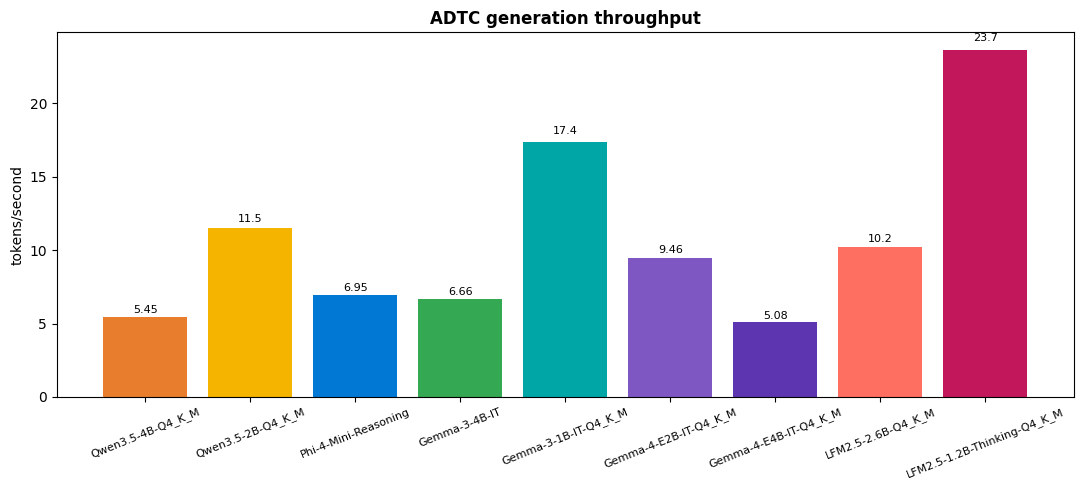

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_tps.png


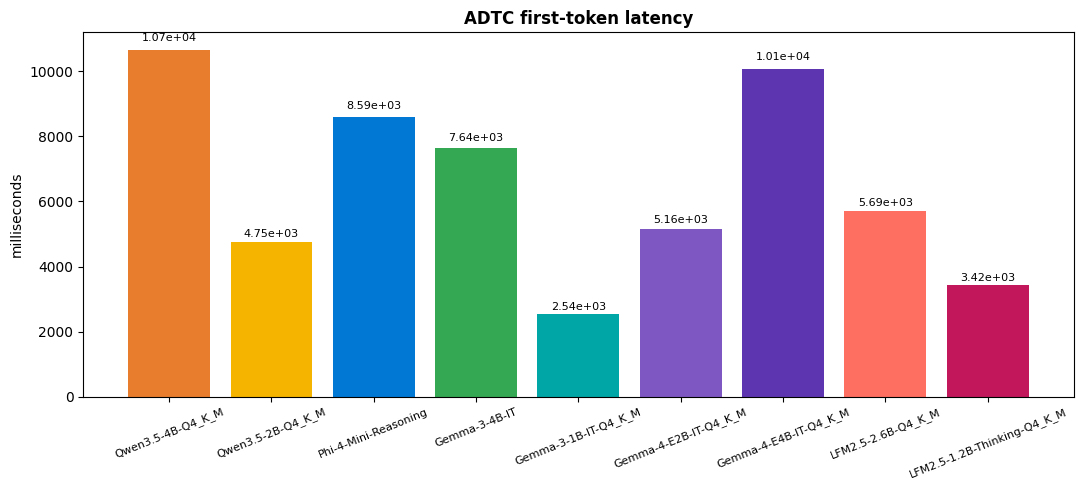

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_ttft.png


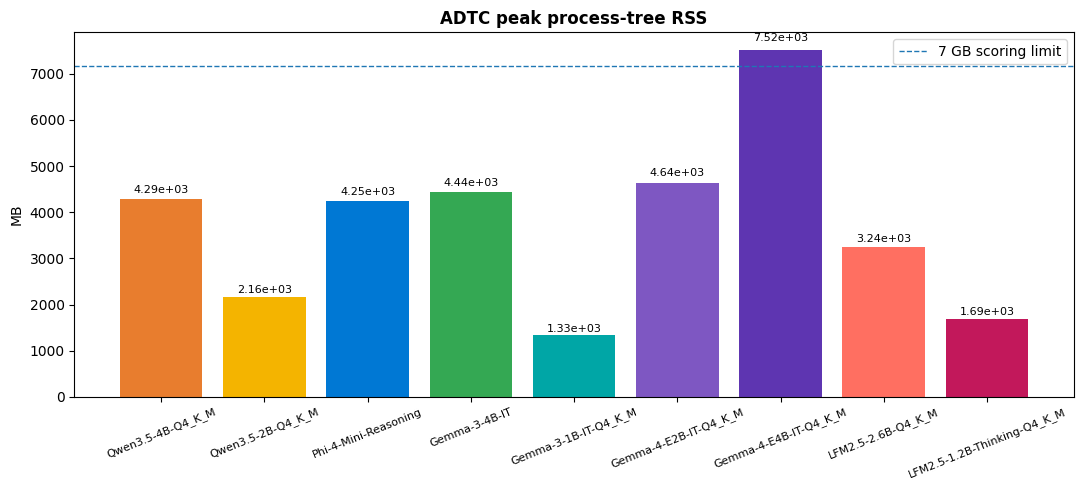

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_peak_ram.png


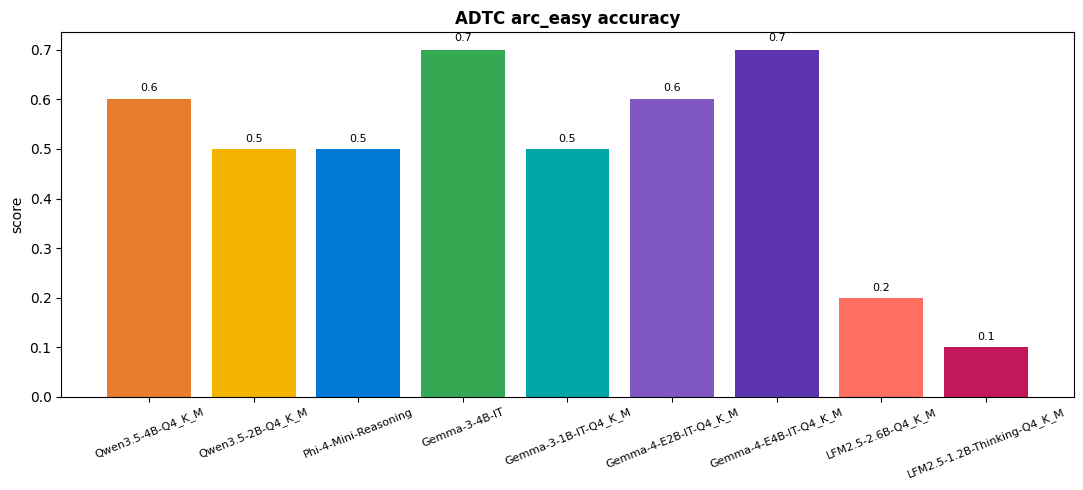

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_accuracy.png


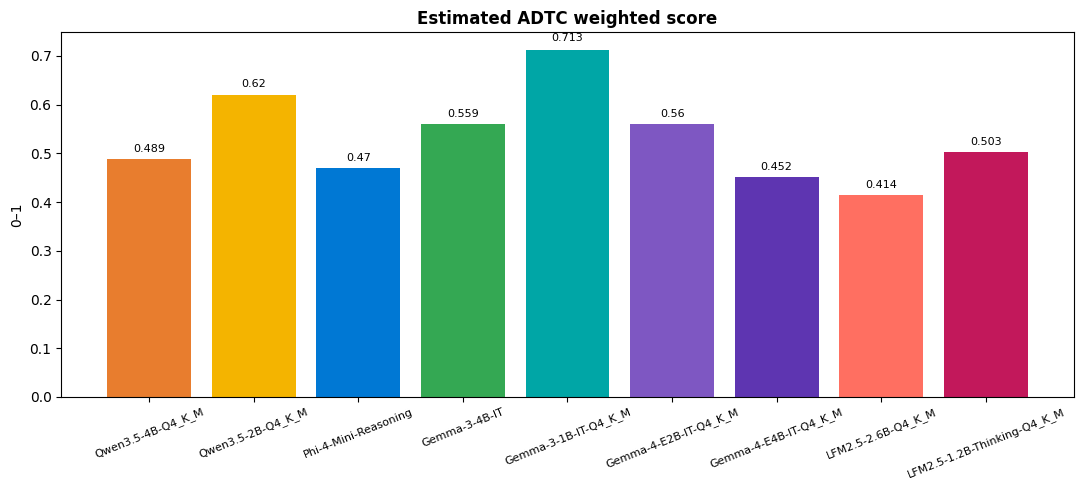

Saved: /kaggle/working/mufasar_profiler_artifacts/adtc_score.png


In [8]:
# 8. Visualise only metrics generated by the official profiler.
plot_data = summary.copy()
plot_data["generation_tps"] = pd.to_numeric(
    plot_data["generation_tps"], errors="coerce"
)
plot_data["first_token_latency_ms"] = pd.to_numeric(
    plot_data["first_token_latency_ms"], errors="coerce"
)
plot_data["peak_rss_mb"] = pd.to_numeric(
    plot_data["peak_rss_mb"], errors="coerce"
)
plot_data["accuracy_score"] = pd.to_numeric(
    plot_data["accuracy_score"], errors="coerce"
)
plot_data["estimated_score"] = pd.to_numeric(
    plot_data["estimated_score"], errors="coerce"
)

metrics = [
    ("generation_tps", "ADTC generation throughput", "tokens/second", "adtc_tps.png"),
    (
        "first_token_latency_ms",
        "ADTC first-token latency",
        "milliseconds",
        "adtc_ttft.png",
    ),
    ("peak_rss_mb", "ADTC peak process-tree RSS", "MB", "adtc_peak_ram.png"),
    ("accuracy_score", f"ADTC {ACCURACY_TASK} accuracy", "score", "adtc_accuracy.png"),
    ("estimated_score", "Estimated ADTC weighted score", "0–1", "adtc_score.png"),
]

for column, title, ylabel, filename in metrics:
    current = plot_data[plot_data[column].notna()].copy()
    if current.empty:
        print(f"Skipping {column}: no numeric profiler results")
        continue

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [MODELS[name]["color"] for name in current["model"]]
    bars = ax.bar(current["model"], current[column], color=colors)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=22, labelsize=8)

    if column == "peak_rss_mb":
        ax.axhline(
            7 * 1024,
            linestyle="--",
            linewidth=1,
            label="7 GB scoring limit",
        )
        ax.legend()

    for bar, value in zip(bars, current[column]):
        value = float(value)
        offset = max(abs(value) * 0.02, 0.01)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{value:.3g}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    output_path = ARTIFACT_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [9]:
# 9. Final profiler-based recommendation.
valid_perf = summary[
    pd.to_numeric(summary["generation_tps"], errors="coerce").notna()
].copy()
valid_acc = summary[
    pd.to_numeric(summary["accuracy_score"], errors="coerce").notna()
].copy()
valid_score = summary[
    pd.to_numeric(summary["estimated_score"], errors="coerce").notna()
].copy()

if valid_perf.empty:
    print("No model completed the official profiler performance stage.")
else:
    valid_perf["generation_tps"] = pd.to_numeric(
        valid_perf["generation_tps"], errors="coerce"
    )
    valid_perf["first_token_latency_ms"] = pd.to_numeric(
        valid_perf["first_token_latency_ms"], errors="coerce"
    )
    valid_perf["peak_rss_mb"] = pd.to_numeric(
        valid_perf["peak_rss_mb"], errors="coerce"
    )

    best_tps = valid_perf.loc[
        valid_perf["generation_tps"].idxmax(), "model"
    ]
    fastest_ttft = valid_perf.loc[
        valid_perf["first_token_latency_ms"].idxmin(), "model"
    ]
    lowest_ram = valid_perf.loc[
        valid_perf["peak_rss_mb"].idxmin(), "model"
    ]

    best_accuracy = "unavailable"
    if not valid_acc.empty:
        valid_acc["accuracy_score"] = pd.to_numeric(
            valid_acc["accuracy_score"], errors="coerce"
        )
        best_accuracy = valid_acc.loc[
            valid_acc["accuracy_score"].idxmax(), "model"
        ]

    best_weighted = "unavailable"
    if not valid_score.empty:
        valid_score["estimated_score"] = pd.to_numeric(
            valid_score["estimated_score"], errors="coerce"
        )
        best_weighted = valid_score.loc[
            valid_score["estimated_score"].idxmax(), "model"
        ]

    print(
        "\n".join([
            "+-----------------------------------------------------------------------+",
            "|              MUFASAR — ADTC PROFILER RECOMMENDATION                   |",
            "+-----------------------------------------------------------------------+",
            f"| Best generation throughput : {best_tps:<39}|",
            f"| Fastest first-token latency: {fastest_ttft:<39}|",
            f"| Lowest peak RSS            : {lowest_ram:<39}|",
            f"| Best ARC-Easy accuracy     : {best_accuracy:<39}|",
            f"| Best estimated ADTC score  : {best_weighted:<39}|",
            "+-----------------------------------------------------------------------+",
        ])
    )

print("\nArtifacts directory:", ARTIFACT_DIR)
print("Combined reports:", ARTIFACT_DIR / "all_model_profiler_reports.json")
print("Summary CSV:", WORK_DIR / "mufasar_adtc_profiler_summary.csv")


+-----------------------------------------------------------------------+
|              MUFASAR — ADTC PROFILER RECOMMENDATION                   |
+-----------------------------------------------------------------------+
| Best generation throughput : LFM2.5-1.2B-Thinking-Q4_K_M            |
| Fastest first-token latency: Gemma-3-1B-IT-Q4_K_M                   |
| Lowest peak RSS            : Gemma-3-1B-IT-Q4_K_M                   |
| Best ARC-Easy accuracy     : Gemma-3-4B-IT                          |
| Best estimated ADTC score  : Gemma-3-1B-IT-Q4_K_M                   |
+-----------------------------------------------------------------------+

Artifacts directory: /kaggle/working/mufasar_profiler_artifacts
Combined reports: /kaggle/working/mufasar_profiler_artifacts/all_model_profiler_reports.json
Summary CSV: /kaggle/working/mufasar_adtc_profiler_summary.csv
